# Customer Feedback Analysis & AI Response Studio

### Imarticus Data Science Internship Assessment

**Objective:** Develop a Python-based solution to identify critical customer feedback and generate personalized, empathetic response emails using Generative AI. 

### Assessment Coverage

* Load, clean, and analyze customer review data using **Pandas**.
* Identify **1-star and 2-star critical reviews** using transparent rule-based Python logic.
* Extract the **most common complaint keywords** from critical reviews using `Counter`.
* Select **3 detailed critical reviews** for automated response generation.
* Use **Google Gemini Generative AI** to generate short, personalized, and empathetic apology emails addressing the specific complaints.
* Present the key insights and **3 AI-generated response emails** within the Jupyter Notebook. 


In [73]:
# Core imports
import os
import re
import time
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", None)

print("Environment ready.")

Environment ready.


## 1. Load the review dataset

The assessment requires a customer-review dataset containing review text and 1–5 star ratings. This submission uses the supplied `Reviews.csv`. The loader also supports a normal `Reviews.csv` file in the notebook folder, so the code is portable rather than tied to one Windows path.

In [74]:
import os
import pandas as pd

# Automatically find Reviews.csv
DATASET_PATH = None

for root, _, files in os.walk("."):
    if "Reviews.csv" in files:
        DATASET_PATH = os.path.join(root, "Reviews.csv")
        break

if DATASET_PATH is None:
    raise FileNotFoundError("Reviews.csv was not found.")

df = pd.read_csv(DATASET_PATH)

print(f"Loaded: {DATASET_PATH}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
display(df.head(5))

Loaded: .\Smriti_pal_PGA_WD_34\Reviews.csv
Shape: 568,454 rows × 10 columns


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it sm...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the produ...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then li..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got this in addition to the Root Beer Extract I ordered (which was good) and made some ...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,"Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very quick. If your a taffy lover, this is a deal."


## 2. Data Audit & Exploratory Analysis

The dataset is first reviewed to understand its overall structure and quality. This includes checking the dataset size, column data types, descriptive statistics, missing values, duplicate records, rating distribution, and review length. These checks provide an initial understanding of the customer feedback and help identify data-quality issues before the cleaning and analysis stages.

In [75]:
# Data Audit & Exploratory Analysis

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\n" + "=" * 50)
print("DATA TYPES & NON-NULL VALUES")
print("=" * 50)
df.info()

print("\n" + "=" * 50)
print("DESCRIPTIVE STATISTICS")
print("=" * 50)
display(df.describe(include="all").T)

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
display(df.isnull().sum().to_frame("Missing Count"))

print("\n" + "=" * 50)
print("DUPLICATE RECORDS")
print("=" * 50)
print(f"Duplicate rows: {df.duplicated().sum():,}")

print("\n" + "=" * 50)
print("RATING DISTRIBUTION")
print("=" * 50)
display(df["Score"].value_counts().sort_index().to_frame("Review Count"))

print("\n" + "=" * 50)
print("REVIEW LENGTH")
print("=" * 50)
display(
    df["Text"].fillna("").astype(str)
    .str.len()
    .describe()
    .to_frame("Review Length")
)

DATASET OVERVIEW
Rows    : 568,454
Columns : 10

DATA TYPES & NON-NULL VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB

DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Id,568454.0,NaN,NaN,NaN,284227.5,164098.679298,1.0,142114.25,284227.5,426340.75,568454.0
ProductId,568454,74258,B007JFMH8M,913,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UserId,568454,256059,A3OXHLG6DIBRW8,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ProfileName,568428,218415,"C. F. Hill ""CFH""",451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HelpfulnessNumerator,568454.0,NaN,NaN,NaN,1.743817,7.636513,0.0,0.0,0.0,2.0,866.0
HelpfulnessDenominator,568454.0,NaN,NaN,NaN,2.22881,8.28974,0.0,0.0,1.0,2.0,923.0
Score,568454.0,NaN,NaN,NaN,4.183199,1.310436,1.0,4.0,5.0,5.0,5.0
Time,568454.0,NaN,NaN,NaN,1296256604.90242,48043312.332415,939340800.0,1271289600.0,1311120000.0,1332720000.0,1351209600.0
Summary,568427,295742,Delicious!,2462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Text,568454,393579,"This review will make me sound really stupid, but whatever. I don't really care as long as people find out what's real and can avoid my mistakes.<br /><br />I got my wonderful ...",199,NaN,NaN,NaN,NaN,NaN,NaN,NaN



MISSING VALUES


,Missing Count
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0



DUPLICATE RECORDS
Duplicate rows: 0

RATING DISTRIBUTION


,Review Count
Score,
1,52268
2,29769
3,42640
4,80655
5,363122



REVIEW LENGTH


,Review Length
count,568454.000000
mean,436.222083
std,445.339741
min,12.000000
25%,179.000000
50%,302.000000
75%,527.000000
max,21409.000000


## 3. Data Quality Checks and Cleaning

The dataset is cleaned after the initial audit. Duplicate records are removed, while rows with missing **review text or ratings** are removed because they are required for critical-review analysis. Invalid rating values are converted to numeric values and excluded if they cannot be converted. Optional customer/profile fields are retained because they can support email personalization.

The review text is standardized by converting it to lowercase, removing special characters, normalizing whitespace, and removing empty reviews.

In [76]:
import re

# Check that the required columns are available
required_columns = {"Score", "Text"}
if not required_columns.issubset(df.columns):
    raise ValueError("Required columns 'Score' and 'Text' are missing.")

before = len(df)

# Remove exact duplicate rows
df = df.drop_duplicates()

# Remove rows where rating or review text is missing
df = df.dropna(subset=["Score", "Text"])

# Convert ratings to numeric; invalid values become NaN
df["Score"] = pd.to_numeric(df["Score"], errors="coerce")

# Remove rows with invalid ratings
df = df.dropna(subset=["Score"])
df["Score"] = df["Score"].astype(int)

# Clean review text: lowercase, remove special characters,
# and normalize extra spaces
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

df["Cleaned_Text"] = df["Text"].apply(clean_text)

# Remove reviews that become empty after cleaning
df = df[df["Cleaned_Text"].str.len() > 0].reset_index(drop=True)

after = len(df)

print("Data cleaning completed successfully.")
print(f"Rows before cleaning : {before:,}")
print(f"Rows after cleaning  : {after:,}")
print(f"Rows removed         : {before - after:,}")

display(df[["Score", "Text", "Cleaned_Text"]].head(3))

Data cleaning completed successfully.
Rows before cleaning : 568,454
Rows after cleaning  : 568,454
Rows removed         : 0


,Score,Text,Cleaned_Text
0,5,I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it sm...,i have bought several of the vitality canned dog food products and have found them all to be of good quality the product looks more like a stew than a processed meat and it sme...
1,1,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the produ...,product arrived labeled as jumbo salted peanuts the peanuts were actually small sized unsalted not sure if this was an error or if the vendor intended to represent the product ...
2,4,"This is a confection that has been around a few centuries. It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut into tiny squares and then li...",this is a confection that has been around a few centuries it is a light pillowy citrus gelatin with nuts in this case filberts and it is cut into tiny squares and then liberall...


## 4. Rating insights

The distribution confirms the available 1–5 star ratings. Critical feedback is explicitly defined as **1-star OR 2-star**, as required by the assessment.

,Review Count,Percentage
Score,,
1,52268,9.19
2,29769,5.24
3,42640,7.50
4,80655,14.19
5,363122,63.88


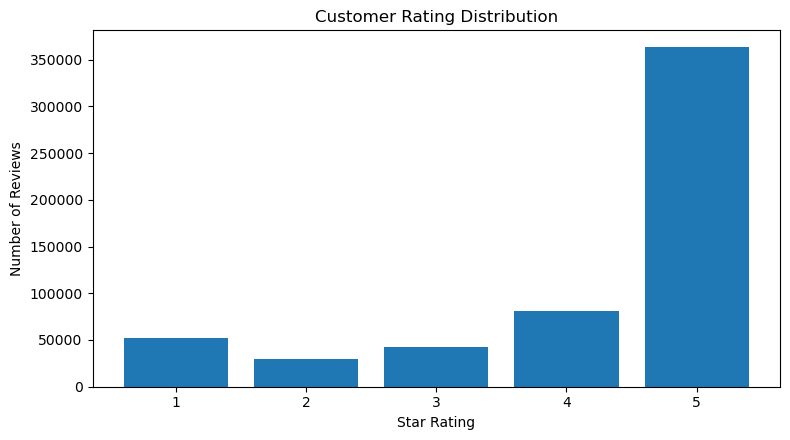

In [77]:
rating_counts = df["Score"].value_counts().sort_index()
rating_distribution = (rating_counts / len(df) * 100).round(2)

summary = pd.DataFrame({"Review Count": rating_counts, "Percentage": rating_distribution})
display(summary)

plt.figure(figsize=(8, 4.5))
plt.bar(summary.index.astype(str), summary["Review Count"])
plt.title("Customer Rating Distribution")
plt.xlabel("Star Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

## 5. Rule-based critical-review filtering

No Machine Learning is used. A review is **Critical** when its rating is 1 or 2 stars. This makes the prioritization transparent and easy to explain to a reviewer.

In [78]:
CRITICAL_RATINGS = {1, 2}
critical_reviews = df[df["Score"].isin(CRITICAL_RATINGS)].copy()

critical_percentage = len(critical_reviews) / len(df) * 100
print(f"Critical reviews (1 or 2 stars): {len(critical_reviews):,}")
print(f"Share of all reviews: {critical_percentage:.2f}%")
print("\nCritical reviews by rating:")
display(critical_reviews["Score"].value_counts().sort_index().rename("Count").to_frame())

Critical reviews (1 or 2 stars): 82,037
Share of all reviews: 14.43%

Critical reviews by rating:


,Count
Score,
1,52268
2,29769


## 6. Complaint keyword analysis

The assessment specifically asks for a function that identifies common complaint keywords using basic string manipulation or `Counter`. The function below uses a curated complaint vocabulary so that generic words do not dominate the result. It also includes product, service, delivery, packaging, return and refund language.

In [79]:
STOP_WORDS = set("""the and is was to of a in for it this that with on my i have had but not be as are at so very they we you me from or an were would could has he she them there their all like just one can these those when will more also really get got much even still make made use used using should thing things way want well good great new first two many lot product food amazon item""".split())

COMPLAINT_KEYWORDS = set("""
broken damaged defective faulty late delay delayed missing wrong refund return rude poor terrible awful
disappointed disappointing problem problems issue issues bad waste expired leak leaking stale rotten unusable
complaint support service delivery shipped shipping packaging package seller vendor quality size defective
replacement charge billing overcharged cancellation damaged missing incorrect unavailable
""".split())

def get_top_complaint_keywords(reviews, complaint_keywords=COMPLAINT_KEYWORDS, top_n=15, text_column="Cleaned_Text"):
    """Return the most frequent complaint-related words in supplied reviews."""
    words = []
    for text in reviews[text_column].dropna():
        words.extend(w for w in text.split() if w not in STOP_WORDS and len(w) > 2)
    counts = Counter(w for w in words if w in complaint_keywords)
    return pd.DataFrame(counts.most_common(top_n), columns=["Complaint Keyword", "Frequency"])

complaint_df = get_top_complaint_keywords(critical_reviews)
print("Top complaint keywords in 1- and 2-star reviews:")
display(complaint_df)

Top complaint keywords in 1- and 2-star reviews:


,Complaint Keyword,Frequency
0,bad,10595
1,disappointed,7281
2,package,5786
3,quality,5678
4,waste,3826
5,problem,3793
6,shipping,3732
7,packaging,3669
8,awful,3287
9,size,3203


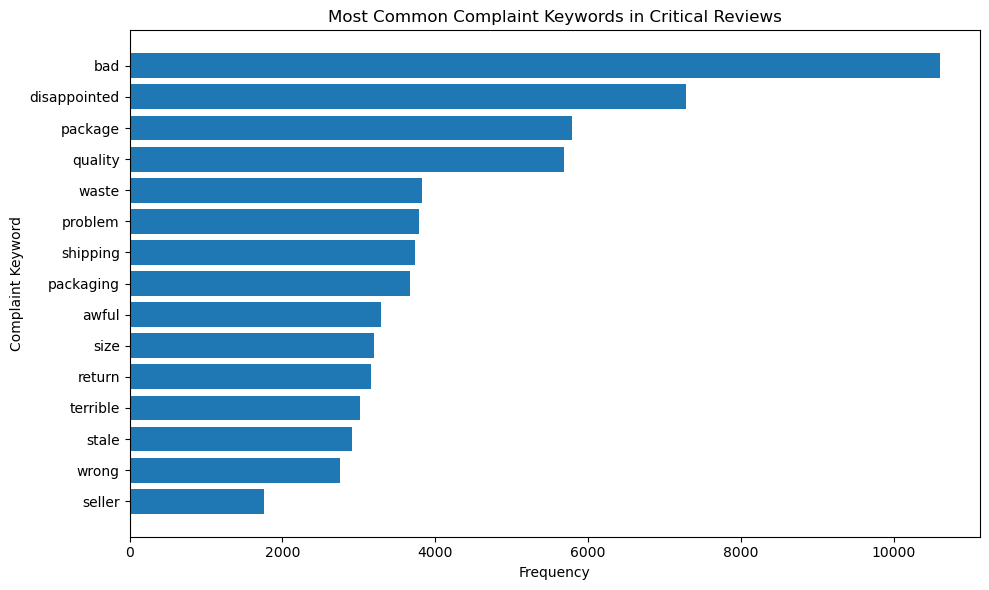

In [80]:
plt.figure(figsize=(10, 6))
plot_df = complaint_df.sort_values("Frequency")
plt.barh(plot_df["Complaint Keyword"], plot_df["Frequency"])
plt.title("Most Common Complaint Keywords in Critical Reviews")
plt.xlabel("Frequency")
plt.ylabel("Complaint Keyword")
plt.tight_layout()
plt.show()

## 7. Select the 3 most critical and detailed reviews

To avoid selecting only long reviews, a transparent priority score combines: **rating severity, complaint-keyword count, review detail, and helpfulness signal**. Because this improved version is explicitly designed to work with both 1- and 2-star feedback, it guarantees representation of each rating when both are available, then selects the strongest remaining candidate.

In [81]:
def add_priority_features(reviews):
    result = reviews.copy()
    result["Review_Length"] = result["Cleaned_Text"].str.split().str.len()
    result["Complaint_Keywords"] = result["Cleaned_Text"].map(
        lambda text: sorted(set(w for w in text.split() if w in COMPLAINT_KEYWORDS))
    )
    result["Complaint_Count"] = result["Complaint_Keywords"].str.len()
    result["Severity_Score"] = result["Score"].map({1: 2, 2: 1}).fillna(0)
    denominator = result["HelpfulnessDenominator"].replace(0, pd.NA) if "HelpfulnessDenominator" in result else pd.Series(pd.NA, index=result.index)
    if "HelpfulnessNumerator" in result and "HelpfulnessDenominator" in result:
        result["Helpfulness_Ratio"] = (result["HelpfulnessNumerator"] / denominator).fillna(0)
    else:
        result["Helpfulness_Ratio"] = 0
    result["Priority_Score"] = (
        result["Severity_Score"] * 5
        + result["Complaint_Count"] * 3
        + result["Review_Length"].clip(upper=300) / 100
        + result["Helpfulness_Ratio"]
    )
    return result

critical_scored = add_priority_features(critical_reviews)

def select_top_critical_reviews(reviews, n=3):
    """Select detailed critical reviews while ensuring 1- and 2-star coverage when possible."""
    ranked = reviews.sort_values(
        ["Priority_Score", "Review_Length"], ascending=[False, False]
    )
    selected_indices = []
    for rating in (1, 2):
        candidates = ranked[(ranked["Score"] == rating) & (~ranked.index.isin(selected_indices))]
        if not candidates.empty and len(selected_indices) < n:
            selected_indices.append(candidates.index[0])
    remaining = ranked[~ranked.index.isin(selected_indices)]
    selected_indices.extend(remaining.head(max(0, n - len(selected_indices))).index.tolist())
    return ranked.loc[selected_indices].copy()

selected_reviews = select_top_critical_reviews(critical_scored, n=3)

print("Selected reviews for GenAI outreach:")
display(selected_reviews[["Score", "Review_Length", "Complaint_Count", "Priority_Score", "Summary"]])

Selected reviews for GenAI outreach:


C:\Users\SMRITI\AppData\Local\Temp\ipykernel_9820\1904567811.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  result["Helpfulness_Ratio"] = (result["HelpfulnessNumerator"] / denominator).fillna(0)


,Score,Review_Length,Complaint_Count,Priority_Score,Summary
148921,1,1400,13,52.500,"Very cheap product, have had to get replacements many times!"
441233,2,566,10,39.000,A few words of caution
81662,1,311,11,46.975,"Bad Packaging, Great product but can't recommend shipping"


In [82]:
for i, (_, row) in enumerate(selected_reviews.iterrows(), start=1):
    print(f"--- Selected Review {i} | {row['Score']} stars | {row['Review_Length']} words ---")
    print(row["Text"][:1500])
    print()

--- Selected Review 1 | 1 stars | 1400 words ---
I have never reviewed an item before, but taking the time to review the Baby Brezza because of the unfortunate experiences I have had with this product and to warn people not to spend $100 on such a poorly made product.. I read multiple reviews on the Baby Brezza and read some negative reviews about the blade not working. But I tend to go with positive reviews if they outweigh the negative ones, but from now on, I will definitely reconsider buying anything with negative reviews, and the Baby Brezza purchase has actually discouraged me from buying anything from Amazon that is expensive and can be broken, as you cannot return the product after 30 days.<br /><br />I bought the BB in February 2012 and should have returned it right away after I had some problems from the beginning, but I was too excited to use it so I did not.<br /><br />1. The cover never fit quite right. The manual said that the blade has two positions, up for steaming and 

## 8. Issue-aware email personalization

The email prompt does more than produce a generic apology. It first identifies the complaint context from the review and interviewer-provided details. The response should adapt its wording to **product issues, service issues, delivery problems, refunds/returns, billing, packaging, quality issues, or other complaints**.

The prompt also prevents unsupported promises: the model must not invent refunds, replacements, investigations, escalations or policy outcomes unless the interviewer explicitly provides them.

In [83]:
ISSUE_RULES = {
    "Product / Quality": {"broken", "damaged", "defective", "faulty", "stale", "rotten", "leak", "leaking", "quality", "wrong", "size"},
    "Service / Support": {"rude", "support", "service", "complaint", "response", "help"},
    "Delivery / Shipping": {"late", "delay", "delayed", "shipping", "shipped", "delivery", "package", "packaging", "missing"},
    "Refund / Return / Billing": {"refund", "return", "billing", "charge", "overcharged", "cancellation", "replacement"},
}

def detect_issue_types(review_text):
    words = set(clean_text(review_text).split())
    matches = [category for category, terms in ISSUE_RULES.items() if words & terms]
    return matches or ["General Complaint"]

for _, row in selected_reviews.iterrows():
    print(row["Score"], "stars →", detect_issue_types(row["Text"]))

1 stars → ['Product / Quality', 'Service / Support', 'Refund / Return / Billing']
2 stars → ['Product / Quality', 'Delivery / Shipping', 'Refund / Return / Billing']
1 stars → ['Product / Quality', 'Delivery / Shipping', 'Refund / Return / Billing']


## 9. Gemini setup

The current Google GenAI Python SDK uses `from google import genai` and `client.models.generate_content(...)`. The notebook uses an environment variable for safer key handling, with a secure `getpass` fallback. See the official Gemini documentation linked in the README.

In [85]:
# Run once if needed:
# %pip install -U google-genai ipywidgets

from getpass import getpass

GEMINI_MODEL = "gemini-3.5-flash-lite"
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if not GEMINI_API_KEY:
    print("GEMINI_API_KEY is not set. Enter it only when you are ready to call the API.")
    GEMINI_API_KEY = getpass("Gemini API key (input hidden): ")    # API key -->>  # AQ.Ab8RN6LbMQKgVQVzZgXWFRKhZCMn0ZkzP8U8Vf7MtWCbr8tPTw

from google import genai
client = genai.Client(api_key=GEMINI_API_KEY)
print(f"Gemini client ready: {GEMINI_MODEL}")

GEMINI_API_KEY is not set. Enter it only when you are ready to call the API.


Gemini API key (input hidden):  ········


Gemini client ready: gemini-3.5-flash-lite


In [86]:
EMAIL_PROMPT = """
You are a senior Customer Support Agent writing a professional customer-service email.

Create a concise, warm, highly personalized response to the customer's critical review.

CUSTOMER NAME: {customer_name}
RATING: {rating}/5
PRODUCT OR SERVICE: {product}
ISSUE TYPE(S): {issue_types}
CUSTOMER REVIEW: {review}
ADDITIONAL DETAILS PROVIDED BY SUPPORT STAFF: {additional_details}
DESIRED RESOLUTION / ACTION THE COMPANY HAS AUTHORIZED: {resolution}
AGENT NAME: {agent_name}
TONE: {tone}

Requirements:
1. Include a clear, professional subject line.
2. Address the customer by name when a name is provided; otherwise use a neutral greeting.
3. Acknowledge the specific problem(s), not just that the customer is unhappy.
4. Tailor the response to the issue type: product/quality, service/support, delivery/shipping, refund/return/billing, packaging, or another issue.
5. Show genuine empathy and take responsibility for the poor experience without blaming the customer.
6. If an authorized resolution is provided, explain it accurately and naturally. If none is provided, do not invent one.
7. Never invent refunds, replacements, credits, investigations, escalations, policy changes, timelines, or company actions.
8. Do not mention AI, prompts, keyword analysis, or internal scoring.
9. Keep it professional and effective, around 120–180 words unless the details require slightly more.
10. End with a helpful, human sign-off from the named agent when provided.
11. Return only the email, with the subject on the first line.
"""

from google.genai import errors

def generate_email(
    review,
    rating,
    customer_name="",
    product="",
    issue_types=None,
    additional_details="",
    resolution="",
    agent_name="Customer Support Team",
    tone="Professional and empathetic",
    max_retries=3
):
    """Generate a personalized customer-support email with retry handling."""

    if rating not in (1, 2):
        raise ValueError(
            "This workflow is intended for critical 1- or 2-star reviews."
        )

    issue_types = issue_types or detect_issue_types(review)

    prompt = EMAIL_PROMPT.format(
        customer_name=customer_name or "Not provided",
        rating=rating,
        product=product or "Not provided",
        issue_types=", ".join(issue_types) if issue_types else "General complaint",
        review=review.strip(),
        additional_details=additional_details or "None",
        resolution=(
            resolution
            or "No specific resolution authorized; do not promise one."
        ),
        agent_name=agent_name or "Customer Support Team",
        tone=tone,
    )

    for attempt in range(1, max_retries + 1):

        try:
            response = client.models.generate_content(
                model=GEMINI_MODEL,
                contents=prompt,
            )

            if response and response.text:
                return response.text.strip()

            raise RuntimeError("Gemini returned an empty response.")

        except errors.ServerError:

            if attempt < max_retries:

                wait_time = 2 ** attempt

                print(
                    f"Gemini is temporarily unavailable. "
                    f"Retrying ({attempt}/{max_retries}) "
                    f"in {wait_time} seconds..."
                )

                time.sleep(wait_time)

            else:

                return (
                    "[AI generation temporarily unavailable]\n\n"
                    "Gemini is currently experiencing high demand. "
                    "Please try generating this email again later."
                )

        except Exception as e:

            return (
                "[AI generation failed]\n\n"
                f"Error: {type(e).__name__}: {e}"
            )

print("Email generation function created successfully.")

Email generation function created successfully.


## 10. Generate the required 3 AI response emails

Run the next cell after configuring the Gemini API key. It generates one personalized email for each selected 1-/2-star review and displays them as the notebook's final output artifact.

In [87]:
generated_emails = []

for i, (_, row) in enumerate(selected_reviews.iterrows(), start=1):
    print(f"Generating email {i}/3...")
    email = generate_email(
        review=row["Text"],
        rating=int(row["Score"]),
        customer_name=row.get("ProfileName", ""),
        product=row.get("ProductId", ""),
        issue_types=detect_issue_types(row["Text"]),
        additional_details=f"Complaint keywords: {', '.join(row['Complaint_Keywords'])}",
    )
    generated_emails.append(email)
    time.sleep(1)

print("All 3 AI-generated emails are ready.")

Generating email 1/3...
Generating email 2/3...
Generating email 3/3...
All 3 AI-generated emails are ready.


In [88]:
from IPython.display import Markdown, display

for i, email in enumerate(generated_emails, start=1):
    display(Markdown(f"### AI-Generated Response Email {i}\n\n{email}"))

### AI-Generated Response Email 1

Subject: Following up on your Baby Brezza experience and feedback

Dear mamavivian,

Thank you for taking the time to share such detailed feedback regarding your Baby Brezza, your ongoing struggles with the replacement units, and the frustrating support experiences you encountered along the way. 

We are truly sorry for the cascade of quality issues you faced—from the ill-fitting covers and grain basket to the driveshaft, leaking water, and recurring blade malfunctions. It is completely understandable that dealing with phone tag, unhelpful interactions with some of our team members, and a defective replacement left you exhausted and disappointed, especially when trying to prepare meals for your little one. We take full responsibility for the frustration and stress this entire process caused you and your family. 

While we are glad one of our representatives was able to step in and try to assist you, we deeply regret that the final resolution still fell short of expectations and that the product did not deliver the reliability you deserved. Your comments regarding product consistency and customer service have been shared internally. 

Please feel free to reply directly to this email if there is anything further we can assist you with regarding your experience. 

Warmly,

Customer Support Team

### AI-Generated Response Email 2

Subject: Following up on your experience with B000EVQWKC

Dear smithj,

Thank you for taking the time to share such a detailed and surprisingly humorous review about your experience with our sugar-free gummy bears (B000EVQWKC). While I had a chuckle reading about the "diarrhea bears," I am truly sorry for the genuinely miserable weekend your family endured after enjoying a modest serving. 

Eating a new product on an empty stomach only to face such intense digestive distress—not once, but twice for a household of five sharing just two bathrooms—sounds like an absolute nightmare. I also apologize for the lack of a clear serving size and expiration date on the packaging, as well as any frustration regarding the hard texture and the Lycasin ingredient. 

We completely take responsibility for this poor product experience. I am very glad to hear that Amazon was able to promptly issue you a refund, and while we cannot offer any further actions at this time, please know that your valuable feedback regarding the labeling and quality has been duly noted. 

Thank you again for your candidness and for keeping such a great sense of humor. 

Warmly,

Customer Support Team

### AI-Generated Response Email 3

Subject: Regarding your recent order of B001VDXO3K

Dear HealthyeOne,

Thank you for taking the time to share your experience with us. I am so sorry to hear about the leaking packaging and the terrible smell you encountered upon opening your recent delivery of coconut water, especially during such high summer temperatures. Having half of your 6-pack arrive damaged is incredibly frustrating, and dealing with spoiled contents is certainly not the convenient shopping experience you rely on us to provide. 

I also completely understand your frustration with the return process. It is entirely reasonable that you wanted to keep the three undamaged boxes rather than having to clean, repackage, and return spoiled items, especially when you live an hour away from the nearest store and ordered online specifically to save time. 

We truly value your feedback regarding our packaging and shipping issues, as it helps us understand where we need to improve. Thank you for noting that the product itself is great, and I am sorry that this delivery fell short of your expectations. 

Sincerely,

Customer Support Team

## 11. Email Studio — Editable AI Workspace

The Email Studio provides a simple and user-friendly workspace for handling **1-star and 2-star customer reviews**. It allows the agent to enter new customer and review details and create a suitable response.

The agent can:

* Enter the **customer name, product/service, rating, and review**.
* **Auto-detect or manually select** the complaint type.
* Add additional details or an **authorized resolution**.
* Choose a suitable **email tone**.
* Generate a **personalized AI-powered customer-service email**.
* **Edit the generated email** before finalizing it.
* Save the final edited email for **review or future export**.

This makes the email-generation process flexible, personalized, and easy to use for different types of customer complaints.


In [89]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# ============================================================
# ISSUE DETECTION
# ============================================================

def studio_detect_issue(review):
    text = review.lower()

    keywords = {
        "Delay / Late Delivery": ["late", "delay", "delayed", "overdue", "still waiting"],
        "Damaged / Defective Product": ["damaged", "broken", "defective", "cracked", "faulty", "not working"],
        "Refund / Billing / Payment": ["refund", "billing", "payment", "charged", "charge", "money back"],
        "Return / Replacement": ["return", "replacement", "replace", "exchange"],
        "Website / App / Technical Issue": ["website", "app", "login", "technical", "error", "bug", "crash"],
        "Customer Service / Support": ["customer service", "support", "agent", "staff", "rude", "unhelpful"],
        "Packaging / Missing Items": ["packaging", "missing item", "missing", "box", "seal"],
        "Price / Pricing Issue": ["price", "pricing", "expensive", "cost", "discount"],
        "Order Issue": ["order", "ordered", "wrong order", "cancel order"],
        "Delivery / Shipping": ["delivery", "shipping", "shipment", "courier", "parcel", "arrived"],
        "Product / Quality": ["quality", "poor quality", "cheap", "product issue"]
    }

    for issue, words in keywords.items():
        if any(word in text for word in words):
            return [issue]

    try:
        detected = detect_issue_types(review)
        if detected:
            return detected
    except Exception:
        pass

    return ["Other / General Complaint"]


# ============================================================
# INPUT FIELDS
# ============================================================

name_box = widgets.Text(
    placeholder="Customer name (optional)",
    layout=widgets.Layout(width="100%", height="35px")
)

rating_box = widgets.ToggleButtons(
    options=[("⭐ 1 Star", 1), ("⭐⭐ 2 Stars", 2)],
    value=1
)

product_box = widgets.Text(
    placeholder="Product or service name (optional)",
    layout=widgets.Layout(width="100%", height="35px")
)

issue_box = widgets.Dropdown(
    options=[
        ("🤖 Auto-detect from review", "Auto-detect"),
        ("📦 Product / Quality", "Product / Quality"),
        ("⚠️ Damaged / Defective Product", "Damaged / Defective Product"),
        ("🚚 Delivery / Shipping", "Delivery / Shipping"),
        ("🕐 Delay / Late Delivery", "Delay / Late Delivery"),
        ("👩‍💼 Customer Service / Support", "Customer Service / Support"),
        ("💳 Refund / Billing / Payment", "Refund / Billing / Payment"),
        ("🔄 Return / Replacement", "Return / Replacement"),
        ("📱 Website / App / Technical Issue", "Website / App / Technical Issue"),
        ("🎁 Packaging / Missing Items", "Packaging / Missing Items"),
        ("💰 Price / Pricing Issue", "Price / Pricing Issue"),
        ("📋 Order Issue", "Order Issue"),
        ("❓ Other / General Complaint", "Other / General Complaint")
    ],
    value="Auto-detect",
    layout=widgets.Layout(width="100%", height="35px")
)

review_box = widgets.Textarea(
    placeholder="Enter or paste the customer's review here...",
    layout=widgets.Layout(width="100%", height="125px")
)

details_box = widgets.Textarea(
    placeholder="Optional: Add important facts, order details, or an authorized resolution...",
    layout=widgets.Layout(width="100%", height="75px")
)

tone_box = widgets.Dropdown(
    options=[
        "Professional and empathetic",
        "Warm and reassuring",
        "Concise and formal",
        "Friendly but professional"
    ],
    value="Professional and empathetic",
    layout=widgets.Layout(width="100%", height="35px")
)

generate_button = widgets.Button(
    description="✨ Generate Email",
    button_style="primary",
    layout=widgets.Layout(width="165px", height="38px")
)

clear_button = widgets.Button(
    description="Clear",
    layout=widgets.Layout(width="90px", height="38px")
)

save_button = widgets.Button(
    description="💾 Save Final Email",
    button_style="success",
    layout=widgets.Layout(width="155px", height="38px")
)

email_box = widgets.Textarea(
    placeholder="Your personalized customer-service email will appear here.\n\nYou can edit the generated email before saving it.",
    layout=widgets.Layout(width="100%", height="230px")
)

status = widgets.Output()


# ============================================================
# BUTTON FUNCTIONS
# ============================================================

def generate_studio_email(_):
    with status:
        clear_output()

        review = review_box.value.strip()

        if not review:
            print("⚠️ Please enter the customer's review first.")
            return

        issue_types = (
            studio_detect_issue(review)
            if issue_box.value == "Auto-detect"
            else [issue_box.value]
        )

        print(f"🔎 Issue: {', '.join(issue_types)}")

        try:
            print("⏳ Generating personalized response...")

            email_box.value = generate_email(
                review=review,
                rating=int(rating_box.value),
                customer_name=name_box.value.strip(),
                product=product_box.value.strip(),
                issue_types=issue_types,
                additional_details=details_box.value.strip(),
                tone=tone_box.value
            )

            print("✅ Email generated successfully.")
            print("✏️ You can edit the response before saving.")

        except Exception as e:
            print(f"❌ Email generation failed: {type(e).__name__}: {e}")


def clear_studio(_):
    name_box.value = ""
    rating_box.value = 1
    product_box.value = ""
    issue_box.value = "Auto-detect"
    review_box.value = ""
    details_box.value = ""
    tone_box.value = "Professional and empathetic"
    email_box.value = ""

    with status:
        clear_output()
        print("🧹 Form cleared. Ready for a new review.")


def save_studio_email(_):
    with status:
        clear_output()

        if not email_box.value.strip():
            print("⚠️ Generate an email before saving.")
            return

        globals()["final_edited_email"] = email_box.value.strip()
        print("✅ Final edited email saved.")
        print("📌 Saved as: final_edited_email")


generate_button.on_click(generate_studio_email)
clear_button.on_click(clear_studio)
save_button.on_click(save_studio_email)


# ============================================================
# UI
# ============================================================

display(widgets.VBox([

    widgets.HTML("""
    <div style="
        padding:20px 22px;
        margin-bottom:18px;
        border-radius:10px;
        border:1px solid #d9d9d9;
    ">
        <div style="font-size:24px;font-weight:600;margin-bottom:6px;">
            📧 Customer Support Email Studio
        </div>
        <div style="font-size:14px;opacity:0.75;">
            Generate personalized responses for critical
            <b>1-star and 2-star customer reviews</b>.
        </div>
    </div>
    """),

    widgets.HTML("<h4>👤 Customer Information</h4>"),
    name_box,

    widgets.HTML("<b>Review Rating</b>"),
    rating_box,
    product_box,

    widgets.HTML("<h4>🔎 Complaint Details</h4>"),
    issue_box,

    widgets.HTML("<h4>📝 Customer Review</h4>"),
    review_box,

    widgets.HTML("<h4>📌 Additional Information</h4>"),
    details_box,

    widgets.HTML("<h4>🎨 Response Style</h4>"),
    tone_box,

    widgets.HBox(
        [generate_button, clear_button],
        layout=widgets.Layout(gap="10px", margin="16px 0 8px 0")
    ),

    status,

    widgets.HTML("""
        <h4>✉️ Generated Email</h4>
        <div style="font-size:12px;opacity:0.7;">
            Review and edit the AI response before saving the final version.
        </div>
    """),

    email_box,

    widgets.HBox(
        [save_button],
        layout=widgets.Layout(
            justify_content="flex-start",
            margin="10px 0 0 0"
        )
    )

], layout=widgets.Layout(width="100%", max_width="900px")))

## 12. Final results table

The table below captures the critical review details and the generated outreach, making the workflow easy to audit.

In [90]:
results = selected_reviews[["Id", "Score", "Summary", "Complaint_Keywords", "Review_Length", "Priority_Score"]].copy()
if len(generated_emails) == len(results):
    results["Generated_Email"] = generated_emails
results

,Id,Score,Summary,Complaint_Keywords,Review_Length,Priority_Score,Generated_Email
148921,148922,1,"Very cheap product, have had to get replacements many times!","[broken, charge, defective, issue, leaking, problems, refund, replacement, return, rude, service, size, terrible]",1400,52.500,"Subject: Following up on your Baby Brezza experience and feedback\n\nDear mamavivian,\n\nThank you for taking the time to share such detailed feedback regarding your Baby Brezz..."
441233,441234,2,A few words of caution,"[bad, expired, issue, late, package, poor, problems, refund, shipping, size]",566,39.000,"Subject: Following up on your experience with B000EVQWKC\n\nDear smithj,\n\nThank you for taking the time to share such a detailed and surprisingly humorous review about your e..."
81662,81663,1,"Bad Packaging, Great product but can't recommend shipping","[awful, damaged, issues, leaking, package, packaging, problem, refund, return, size, terrible]",311,46.975,"Subject: Regarding your recent order of B001VDXO3K\n\nDear HealthyeOne,\n\nThank you for taking the time to share your experience with us. I am so sorry to hear about the leaki..."


## 13. Conclusion

This project provides a **structured and practical approach to customer review analysis and AI-assisted customer support**. It combines Pandas-based analysis, rule-based filtering, complaint keyword analysis, and Generative AI to identify critical feedback and generate appropriate responses.

### Key Areas

1. **Review Analysis:** Customer reviews are processed and analyzed using Pandas.
2. **Critical Reviews:** The solution identifies **both 1-star and 2-star reviews** as high-priority feedback.
3. **Complaint Analysis:** Keywords are used to identify the main customer concerns.
4. **AI Response Generation:** Generative AI creates **professional, personalized, and issue-specific emails**.
5. **Email Studio:** Users can enter customer details, select or auto-detect issues, generate, edit, and save the final response.

### Overall Outcome

The project demonstrates how **data analytics and Generative AI can be integrated into a practical customer-support workflow**, improving the **efficiency, consistency, and quality of customer communication**.

## References

- Pandas documentation: https://pandas.pydata.org/docs/
- Python string methods: https://docs.python.org/3/library/stdtypes.html#string-methods
- Google Gemini API documentation: https://ai.google.dev/gemini-api/docs
- Gemini content generation: https://ai.google.dev/api/generate-content
